In [1]:
# import requried libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load the datasets
df = pd.read_csv("Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [4]:
X=df.iloc[:,2:4].values # age,estimated salary
Y=df.iloc[:,-1].values  # purchased

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [15]:
from sklearn.tree import DecisionTreeClassifier

# Create a decision tree classifier
base_model= DecisionTreeClassifier(max_depth=3)



In [21]:

# Create AdaBoost classifier
classifier = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Train the model
classifier.fit(X_train, Y_train)  # use .fit(), not .fix()
# Make predictions
y_pred = classifier.predict(X_test)


<Axes: >

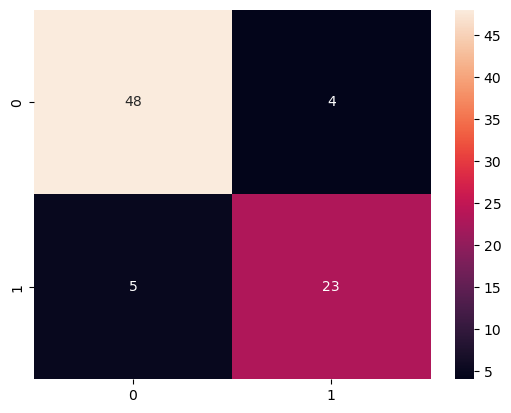

In [22]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(Y_test,y_pred)
sns.heatmap(cm,annot=True)

In [23]:
# find accuracy
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)


0.8875

In [24]:
# find the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test,y_pred)


array([[48,  4],
       [ 5, 23]])

In [25]:
from sklearn.ensemble import GradientBoostingClassifier
classifier=GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=1.0,
    random_state=42)
classifier.fit(X_train,Y_train)


GradientBoostingClassifier(learning_rate=1.0, random_state=42)

In [26]:
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test,y_pred)

array([[48,  4],
       [ 5, 23]])

In [32]:
from xgboost import XGBClassifier

classifier = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

classifier.fit(X_train, Y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)